In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('hospital_readmissions.csv')
print(df.shape) # tells me dimensions of my data set aka how many rows and columns (#rows, #cols)
df.head() # shows 5 rows of data

(25000, 17)


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [2]:
# shows me how readmission is encoded
print(df['readmitted'].value_counts())

print('--------')

# there are no missing values in this dataset
print(df.isnull().sum())

readmitted
no     13246
yes    11754
Name: count, dtype: int64
--------
age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64


In [3]:
# Looks at the breakdown of readmissions by age
# As patients get older, the split between yes/no gets smaller
print(df.groupby('age')['readmitted'].value_counts())

age       readmitted
[40-50)   no            1405
          yes           1127
[50-60)   no            2486
          yes           1966
[60-70)   no            3143
          yes           2770
[70-80)   no            3501
          yes           3336
[80-90)   no            2277
          yes           2239
[90-100)  no             434
          yes            316
Name: count, dtype: int64


In [4]:
# Looks at breakdown of readmission by first diagnosis
# value_counts() sorts by highest count first which is why for diabetes, "yes" appears first
# Diabetes has the highest readmission rate of all diagnoses
print(df.groupby('diag_1')['readmitted'].value_counts())

diag_1           readmitted
Circulatory      no            4074
                 yes           3750
Diabetes         yes            937
                 no             810
Digestive        no            1224
                 yes           1105
Injury           no             939
                 yes            727
Missing          no               2
                 yes              2
Musculoskeletal  no             757
                 yes            495
Other            no            3566
                 yes           2932
Respiratory      no            1874
                 yes           1806
Name: count, dtype: int64


In [5]:
# pandas shortcut to give me the unique diagnosis
df['diag_1'].unique()

<StringArray>
[    'Circulatory',           'Other',          'Injury',       'Digestive',
     'Respiratory',        'Diabetes', 'Musculoskeletal',         'Missing']
Length: 8, dtype: str

In [6]:
diagnoses = df['diag_1'].unique() # gives me an array of strings of all the unique diagnoses
for diag in diagnoses: 
    diag_df = df[df['diag_1'] == diag] # gives me all the rows where the diagnosis matches curr diag
    total = diag_df.shape[0] # gives number of rows aka total # of patients with this diagnosis
    num_readmitted = diag_df[diag_df['readmitted'] == 'yes'].shape[0] # gives number of rows where readmitted is yes
    readmission_rate = (num_readmitted / total) * 100
    print(f"{diag}: {readmission_rate:.1f}%")

Circulatory: 47.9%
Other: 45.1%
Injury: 43.6%
Digestive: 47.4%
Respiratory: 49.1%
Diabetes: 53.6%
Musculoskeletal: 39.5%
Missing: 50.0%


In [7]:
diagnoses_list = []
rates = []

for diag in diagnoses:
    diag_df = df[df['diag_1'] == diag]
    total = diag_df.shape[0]
    num_readmitted = diag_df[diag_df['readmitted'] == 'yes'].shape[0]
    readmission_rate = num_readmitted / total * 100
    diagnoses_list.append(diag)
    rates.append(readmission_rate)

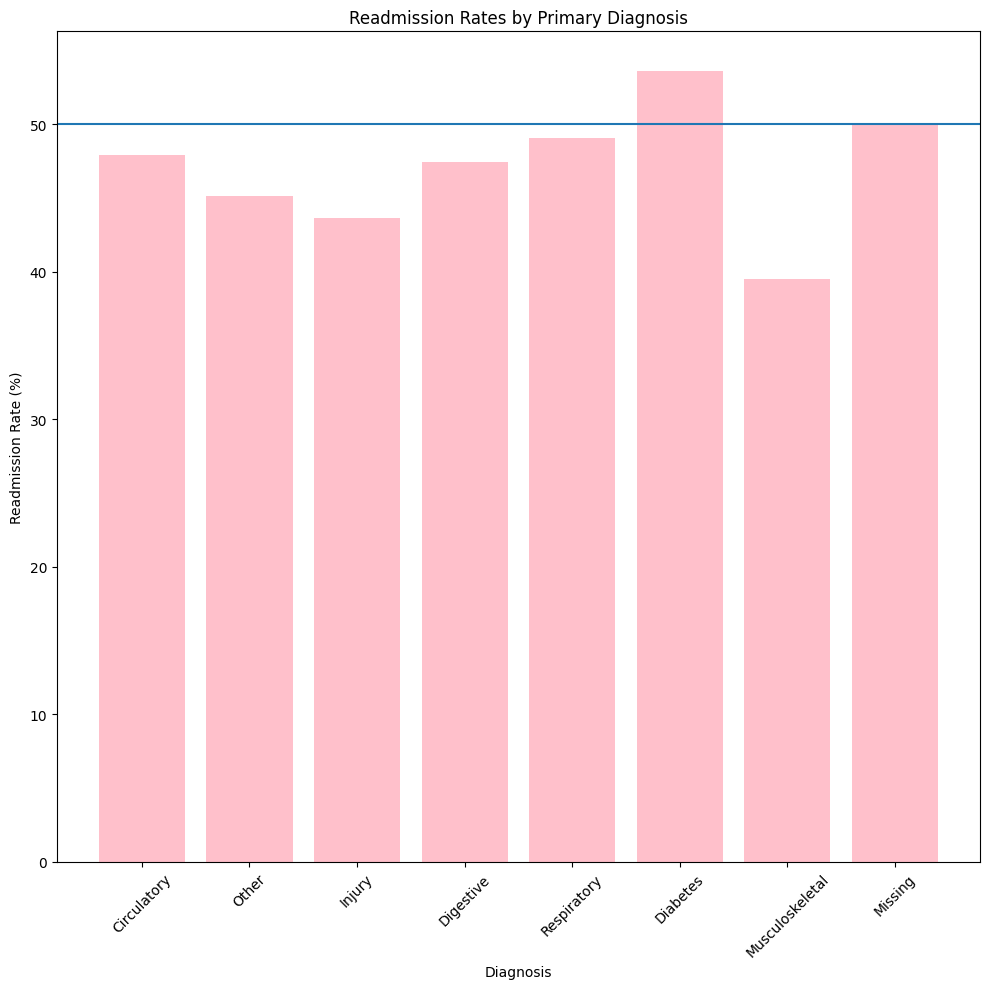

In [8]:
plt.figure(figsize=(10,10))
plt.bar(diagnoses_list, rates, color="pink")
plt.title("Readmission Rates by Primary Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Readmission Rate (%)")
plt.axhline(y=50) # draws a horizontal line to show coin flip threshold
plt.xticks(rotation=45)
plt.tight_layout() # auto adjusts space so nothing gets cut off
plt.show() # displays the chart


In [9]:
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [10]:
df['age'].unique() # gives me a list of all the unique ages

<StringArray>
['[70-80)', '[50-60)', '[60-70)', '[40-50)', '[80-90)', '[90-100)']
Length: 6, dtype: str

In [11]:
agesList = df['age'].unique()
agesList = sorted(list(agesList))
for age in agesList: 
    age_df = df[df['age'] == age] # filters rows for the age group
    total = age_df.shape[0] # gives me total num of rows from this age group
    num_readmitted = age_df[age_df['readmitted'] == 'yes'].shape[0] # gives me the num of rows where readmitted is yes
    readmission_rate = (num_readmitted / total) * 100
    print(f"{age} : {readmission_rate:.1f}%")
    

[40-50) : 44.5%
[50-60) : 44.2%
[60-70) : 46.8%
[70-80) : 48.8%
[80-90) : 49.6%
[90-100) : 42.1%


In [12]:
agesList = df['age'].unique()
agesList = sorted(list(agesList))
readmission_rates = []
for age in agesList: 
    age_df = df[df['age'] == age] # filters rows for the age group
    total = age_df.shape[0] # gives me total num of rows from this age group
    num_readmitted = age_df[age_df['readmitted'] == 'yes'].shape[0] # gives me the num of rows where readmitted is yes
    readmission_rate = (num_readmitted / total) * 100
    print(f"{age} : {readmission_rate:.1f}%")
    readmission_rates.append(readmission_rate)
    

[40-50) : 44.5%
[50-60) : 44.2%
[60-70) : 46.8%
[70-80) : 48.8%
[80-90) : 49.6%
[90-100) : 42.1%


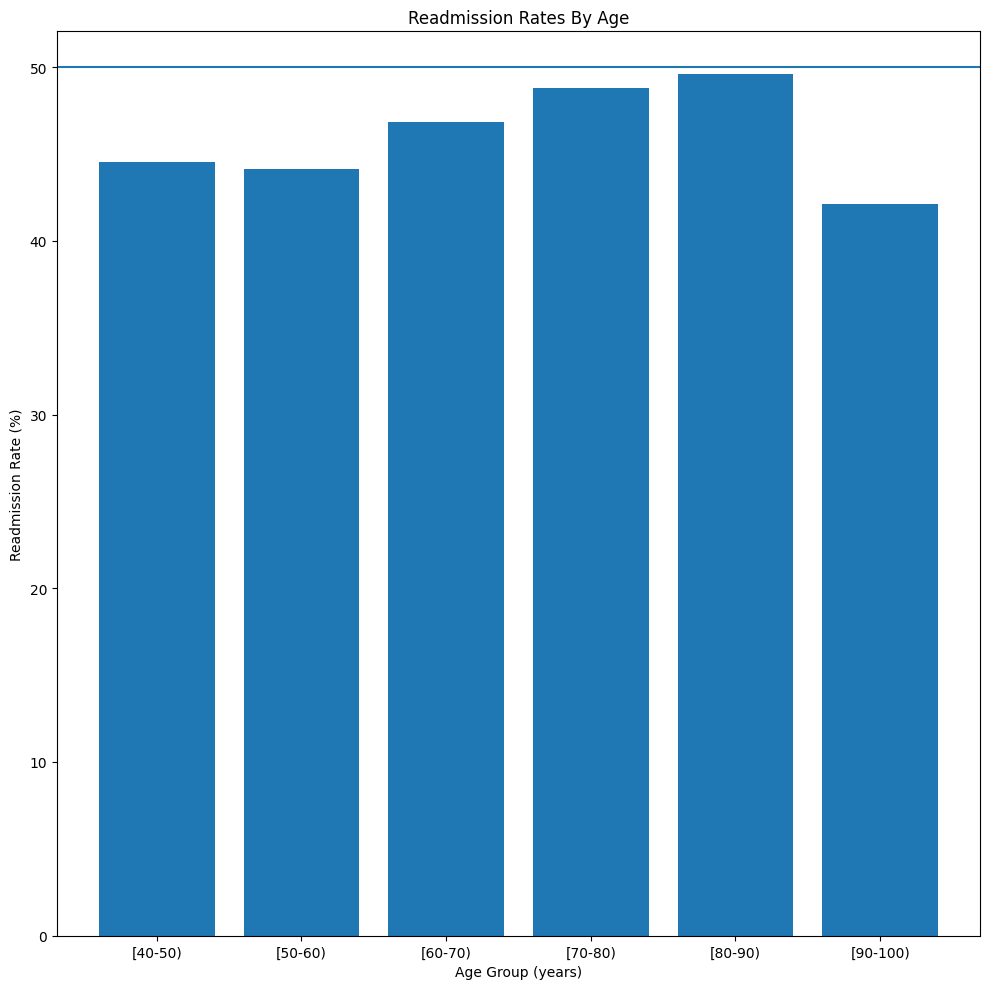

In [13]:
plt.figure(figsize=(10,10))
plt.bar(agesList, readmission_rates)
plt.title("Readmission Rates By Age")
plt.xlabel("Age Group (years)")
plt.ylabel("Readmission Rate (%)")
plt.axhline(y=50)
plt.tight_layout()
plt.show()

In [14]:
print(df.dtypes) # prints data type of each col

age                    str
time_in_hospital     int64
n_lab_procedures     int64
n_procedures         int64
n_medications        int64
n_outpatient         int64
n_inpatient          int64
n_emergency          int64
medical_specialty      str
diag_1                 str
diag_2                 str
diag_3                 str
glucose_test           str
A1Ctest                str
change                 str
diabetes_med           str
readmitted             str
dtype: object


In [15]:
# confirming which cols are binary prior to ecnoding them
# from this, I determined that glucose_test and A1Ctest are not binary!
# binary cols are change, diabetes_med, readmitted
binary_cols = ['glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted']

for col in binary_cols:
    print(f"{col}: {df[col].unique()}")

glucose_test: <StringArray>
['no', 'normal', 'high']
Length: 3, dtype: str
A1Ctest: <StringArray>
['no', 'normal', 'high']
Length: 3, dtype: str
change: <StringArray>
['no', 'yes']
Length: 2, dtype: str
diabetes_med: <StringArray>
['yes', 'no']
Length: 2, dtype: str
readmitted: <StringArray>
['no', 'yes']
Length: 2, dtype: str


In [16]:
# determine how many unique values each categorical col has
categorical_cols = ['glucose_test', 'A1Ctest', 'age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

glucose_test: <StringArray>
['no', 'normal', 'high']
Length: 3, dtype: str
A1Ctest: <StringArray>
['no', 'normal', 'high']
Length: 3, dtype: str
age: <StringArray>
['[70-80)', '[50-60)', '[60-70)', '[40-50)', '[80-90)', '[90-100)']
Length: 6, dtype: str
medical_specialty: <StringArray>
[               'Missing',                  'Other',       'InternalMedicine',
 'Family/GeneralPractice',             'Cardiology',                'Surgery',
       'Emergency/Trauma']
Length: 7, dtype: str
diag_1: <StringArray>
[    'Circulatory',           'Other',          'Injury',       'Digestive',
     'Respiratory',        'Diabetes', 'Musculoskeletal',         'Missing']
Length: 8, dtype: str
diag_2: <StringArray>
[    'Respiratory',           'Other',     'Circulatory',          'Injury',
        'Diabetes',       'Digestive', 'Musculoskeletal',         'Missing']
Length: 8, dtype: str
diag_3: <StringArray>
[          'Other',     'Circulatory',        'Diabetes',     'Respiratory',
          '

In [17]:
# encodes readmitted to yes & no
df_encoded = df.copy() # creates a copy of the dataframe so original raw df is left untouched
df_encoded['readmitted'] = df_encoded['readmitted'].map({'yes': 1, 'no': 0}) # replaces yes with 1 and no with 0
print(df_encoded['readmitted'].unique())

[0 1]


In [18]:
# encodes change and diabetes_med to yes & no
df_encoded['change'] = df_encoded['change'].map({'yes': 1, 'no': 0})
df_encoded['diabetes_med'] = df_encoded['diabetes_med'].map({'yes': 1, 'no': 0})
print(df_encoded['change'].unique())
print(df_encoded['diabetes_med'].unique())

[0 1]
[1 0]


In [19]:
# encodes age 
df_encoded['age'] = df_encoded['age'].map({'[40-50)': 0, '[50-60)': 1,'[60-70)': 2, '[70-80)': 3, '[80-90)':4,'[90-100)':5})
print(df_encoded['age'].unique())

[3 1 2 0 4 5]


In [20]:
# encodes glucose_test & A1Ctest
df_encoded['glucose_test'] = df_encoded['glucose_test'].map({"no": 0, "normal": 1, "high": 2})
df_encoded['A1Ctest'] = df_encoded['A1Ctest'].map({"no": 0, "normal": 1, "high": 2})
print(df_encoded['glucose_test'].unique())
print(df_encoded['A1Ctest'].unique())

[0 1 2]
[0 1 2]


In [21]:
pd.get_dummies(df_encoded['diag_1']) # shows me a preview of the encoded col, does not modify df_encoded!

,Circulatory,Diabetes,Digestive,Injury,Missing,Musculoskeletal,Other,Respiratory
0,True,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,False
2,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False
4,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...
24995,True,False,False,False,False,False,False,False
24996,False,False,True,False,False,False,False,False
24997,False,False,False,False,False,False,True,False
24998,False,False,False,False,False,False,False,True


In [22]:
# modifies df_encoded with one-hot encoded cols for diag_1, diag_2, diag_3 and medical_speciality
df_encoded = pd.get_dummies(df_encoded, columns=['diag_1', 'diag_2', 'diag_3', 'medical_specialty'])


In [23]:
# returns # of rows and cols
df_encoded.shape

(25000, 44)

In [24]:
print(df_encoded.columns.tolist())

['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted', 'diag_1_Circulatory', 'diag_1_Diabetes', 'diag_1_Digestive', 'diag_1_Injury', 'diag_1_Missing', 'diag_1_Musculoskeletal', 'diag_1_Other', 'diag_1_Respiratory', 'diag_2_Circulatory', 'diag_2_Diabetes', 'diag_2_Digestive', 'diag_2_Injury', 'diag_2_Missing', 'diag_2_Musculoskeletal', 'diag_2_Other', 'diag_2_Respiratory', 'diag_3_Circulatory', 'diag_3_Diabetes', 'diag_3_Digestive', 'diag_3_Injury', 'diag_3_Missing', 'diag_3_Musculoskeletal', 'diag_3_Other', 'diag_3_Respiratory', 'medical_specialty_Cardiology', 'medical_specialty_Emergency/Trauma', 'medical_specialty_Family/GeneralPractice', 'medical_specialty_InternalMedicine', 'medical_specialty_Missing', 'medical_specialty_Other', 'medical_specialty_Surgery']


In [26]:
# final preprocessing step to split the df into features (x) and target (y)
# target = what my model will predict aka readmission
# features = everything the model uses to predict (all columns except readmitted)
y = df_encoded['readmitted']
X = df_encoded.drop(columns='readmitted')
print(y.shape) # returns a single column aka series which is a 1D list of value hence why only has # of rows aka length of list
print(X.shape)

(25000,)
(25000, 43)


In [27]:
# X_train & y_train = the 80% that the model learns from
# X_test, y_test = the 20% the model will be tested on
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
  X,y , random_state=100,test_size=0.2, shuffle=True, stratify=y)